## Import and load the data

In [108]:
import os
import glob
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [109]:
import h5py

def get_dataset_name(file_name_with_dir):
    filename_without_dir = file_name_with_dir.split('/')[-1]
    temp = filename_without_dir.split('_')[:-1]
    dataset_name = "_".join(temp)
    return dataset_name

def read_h5_file(filepath):
    with h5py.File(filepath, "r") as f:
        keys = list(f.keys())
        if len(keys) != 1:
            raise ValueError(f"Expected one dataset, found {keys}")
        dataset_name = keys[0]
        X = f[dataset_name][()]
    return X, dataset_name

In [ ]:
DATASET_PATH = "/Users/stijnroos/VisualStudio/DL_data/"

RAW_FOLDERS = {
    "intra_train": os.path.join(DATASET_PATH, "Intra", "train"),
    "intra_test": os.path.join(DATASET_PATH, "Intra", "test"),
    "cross_train": os.path.join(DATASET_PATH, "Cross", "train"),
    "cross_test1": os.path.join(DATASET_PATH, "Cross", "test1"),
    "cross_test2": os.path.join(DATASET_PATH, "Cross", "test2"),
    "cross_test3": os.path.join(DATASET_PATH, "Cross", "test3"),
}

def parse_filename(path):
    name = os.path.basename(path).replace(".h5", "")
    parts = name.split("_")
    subject = parts[-2]
    chunk = int(parts[-1])
    task = "_".join(parts[:-2])
    return task, subject, chunk

rows = []

for split_name, folder in RAW_FOLDERS.items():
    files = sorted(glob.glob(os.path.join(folder, "*.h5")))
    for file in files:
        task, subject, chunk = parse_filename(file)
        rows.append({
            "split": split_name,
            "file": os.path.basename(file),
            "task": task,
            "subject": subject,
            "chunk": chunk,
            "path": file
        })

df_files = pd.DataFrame(rows)


----
## Data preprocessing

1. Mulitply data by 10^15
2. Downsample data by factor 4 using decimate
3. z-score normalise

Do this for the intra and the cross datasets and make overlapping windows to use for a 1D CNN.

In [ ]:
from scipy.signal import decimate

def preprocess_meg(X, downsample_factor=4, eps=1e-12):
    # Convert Tesla-scale values to femtoTesla-like scale
    X = X * 1e15

    # Downsample over time axis
    X = decimate(X, q=downsample_factor, axis=1, zero_phase=True)

    # Z-score per channel within this recording
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True)
    X = (X - mean) / (std + eps)

    return X.astype(np.float32)


def make_windows(X, window_size=512, stride=256):
    windows = []

    for start in range(0, X.shape[1] - window_size + 1, stride):
        end = start + window_size
        windows.append(X[:, start:end])

    return np.stack(windows)

In [ ]:
sample_file = df_files.iloc[0]["path"]
X, dataset_name = read_h5_file(sample_file)

X_processed = preprocess_meg(X, downsample_factor=4)
windows = make_windows(X_processed, window_size=512, stride=256)

print("Processed shape:", X_processed.shape)
print("Windows shape:", windows.shape)
print("Processed mean:", X_processed.mean())
print("Processed std:", X_processed.std())
print("One window shape:", windows[0].shape)

Processed shape: (248, 8906)
Windows shape: (33, 248, 512)
Processed mean: 8.0138957e-10
Processed std: 1.0
One window shape: (248, 512)


In [ ]:
TASK_TO_LABEL = {
    "rest": 0,
    "task_story_math": 1,
    "task_working_memory": 2,
    "task_motor": 3,
}

LABEL_TO_TASK = {v: k for k, v in TASK_TO_LABEL.items()}

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


def load_windowed_split(df_split, window_size=512, stride=256, downsample_factor=4):
    X_all = []
    y_all = []
    file_all = []

    for _, row in df_split.iterrows():
        X_raw, _ = read_h5_file(row["path"])
        X_processed = preprocess_meg(X_raw, downsample_factor=downsample_factor)
        windows = make_windows(X_processed, window_size=window_size, stride=stride)

        label = TASK_TO_LABEL[row["task"]]

        X_all.append(windows)
        y_all.extend([label] * len(windows))
        file_all.extend([row["file"]] * len(windows))

    X_all = np.concatenate(X_all, axis=0)
    y_all = np.array(y_all, dtype=np.int64)
    file_all = np.array(file_all)

    return X_all, y_all, file_all


device = torch.device("mps" if torch.backends.mps.is_available() else 
                      "cuda" if torch.cuda.is_available() else 
                      "cpu")

print("Using device:", device)

class MEGWindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    

#### Apply to Intra set

In [ ]:
df_intra_train = df_files[df_files["split"] == "intra_train"].reset_index(drop=True)
df_intra_test = df_files[df_files["split"] == "intra_test"].reset_index(drop=True)


def prepare_intra_loaders(window_size, stride, batch_size=32):
    X_intra_train, y_intra_train, files_intra_train = load_windowed_split(
        df_intra_train,
        window_size=window_size,
        stride=stride
    )

    X_intra_test, y_intra_test, files_intra_test = load_windowed_split(
        df_intra_test,
        window_size=window_size,
        stride=stride
    )

    gss = GroupShuffleSplit(
        n_splits=1,
        test_size=0.2,
        random_state=42
    )

    train_idx, val_idx = next(
        gss.split(
            X_intra_train,
            y_intra_train,
            groups=files_intra_train
        )
    )

    train_loader = DataLoader(
        MEGWindowDataset(X_intra_train[train_idx], y_intra_train[train_idx]),
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        MEGWindowDataset(X_intra_train[val_idx], y_intra_train[val_idx]),
        batch_size=batch_size,
        shuffle=False
    )

    test_loader = DataLoader(
        MEGWindowDataset(X_intra_test, y_intra_test),
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, val_loader, test_loader



# X_intra_train, y_intra_train, files_intra_train = load_windowed_split(df_intra_train)
# X_intra_test, y_intra_test, files_intra_test = load_windowed_split(df_intra_test)

print("X_intra_train:", X_intra_train.shape)
print("y_intra_train:", y_intra_train.shape)
print("X_intra_test:", X_intra_test.shape)
print("y_intra_test:", y_intra_test.shape)

print("Train class counts:", np.bincount(y_intra_train))
print("Test class counts:", np.bincount(y_intra_test))

X_intra_train: (1056, 248, 512)
y_intra_train: (1056,)
X_intra_test: (264, 248, 512)
y_intra_test: (264,)
Train class counts: [264 264 264 264]
Test class counts: [66 66 66 66]


#### Apply to Cross set

In [73]:
df_cross_train = df_files[df_files["split"] == "cross_train"].reset_index(drop=True)
df_cross_test1 = df_files[df_files["split"] == "cross_test1"].reset_index(drop=True)
df_cross_test2 = df_files[df_files["split"] == "cross_test2"].reset_index(drop=True)
df_cross_test3 = df_files[df_files["split"] == "cross_test3"].reset_index(drop=True)

X_cross_train, y_cross_train, files_cross_train = load_windowed_split(df_cross_train)
X_cross_test1, y_cross_test1, files_cross_test1 = load_windowed_split(df_cross_test1)
X_cross_test2, y_cross_test2, files_cross_test2 = load_windowed_split(df_cross_test2)
X_cross_test3, y_cross_test3, files_cross_test3 = load_windowed_split(df_cross_test3)

print("X_cross_train:", X_cross_train.shape)
print("X_cross_test1:", X_cross_test1.shape)
print("X_cross_test2:", X_cross_test2.shape)
print("X_cross_test3:", X_cross_test3.shape)

print("Train class counts:", np.bincount(y_cross_train))
print("Test1 class counts:", np.bincount(y_cross_test1))
print("Test2 class counts:", np.bincount(y_cross_test2))
print("Test3 class counts:", np.bincount(y_cross_test3))

X_cross_train: (2112, 248, 512)
X_cross_test1: (528, 248, 512)
X_cross_test2: (528, 248, 512)
X_cross_test3: (528, 248, 512)
Train class counts: [528 528 528 528]
Test1 class counts: [132 132 132 132]
Test2 class counts: [132 132 132 132]
Test3 class counts: [132 132 132 132]


---
## Model training

#### Setup model

In [ ]:
# from sklearn.model_selection import GroupShuffleSplit

# gss = GroupShuffleSplit(
#     n_splits=1,
#     test_size=0.2,
#     random_state=42
# )

# train_idx, val_idx = next(
#     gss.split(
#         X_intra_train,
#         y_intra_train,
#         groups=files_intra_train
#     )
# )

# X_train = X_intra_train[train_idx]
# y_train = y_intra_train[train_idx]

# X_val = X_intra_train[val_idx]
# y_val = y_intra_train[val_idx]

# print("Train:", X_train.shape)
# print("Val:", X_val.shape)

# print("Train files:", len(np.unique(files_intra_train[train_idx])))
# print("Val files:", len(np.unique(files_intra_train[val_idx])))

Train: (825, 248, 512)
Val: (231, 248, 512)
Train files: 25
Val files: 7


### 1D Data Loader

In [ ]:
# import torch
# import torch.nn as nn
# from torch.utils.data import Dataset, DataLoader

# device = torch.device("mps" if torch.backends.mps.is_available() else 
#                       "cuda" if torch.cuda.is_available() else 
#                       "cpu")

# print("Using device:", device)

# class MEGWindowDataset(Dataset):
#     def __init__(self, X, y):
#         self.X = torch.tensor(X, dtype=torch.float32)
#         self.y = torch.tensor(y, dtype=torch.long)

#     def __len__(self):
#         return len(self.y)

#     def __getitem__(self, idx):
#         return self.X[idx], self.y[idx]
    

# batch_size = 32


# train_loader = DataLoader(
#     MEGWindowDataset(X_train, y_train),
#     batch_size=batch_size,
#     shuffle=True
# )

# val_loader = DataLoader(
#     MEGWindowDataset(X_val, y_val),
#     batch_size=batch_size,
#     shuffle=False
# )

# test_loader = DataLoader(
#     MEGWindowDataset(X_intra_test, y_intra_test),
#     batch_size=batch_size,
#     shuffle=False
# )

Using device: mps


In [ ]:
##################### 1D CNN Models #####################

class MEG1DCNN1(nn.Module):
    def __init__(self, n_channels=248, n_classes=4, dropout=0.3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(n_channels, 128, kernel_size=7, padding=3),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

class MEG1DCNN2(nn.Module):
    def __init__(self, n_channels=248, n_classes=4, dropout=0.3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(n_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(64, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    

class MEG1DCNN3(nn.Module):
    def __init__(self, n_channels=248, n_classes=4, dropout=0.3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(n_channels, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(16, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))
    

class MEG1DCNN4(nn.Module):
    def __init__(self, n_channels=248, n_classes=4, dropout=None):
        super().__init__()
        self.conv = nn.Conv1d(n_channels, 4, kernel_size=5, padding=2)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(4, n_classes)

    def forward(self, x):
        x = torch.relu(self.conv(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


#### Train Helper Functions

In [100]:
from time import time

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return total_loss / total, correct / total


def train(model, train_loader, val_loader, optimizer, criterion, device, epochs=10, print_every=10):
    best_val_acc = 0
    best_state = None

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict()

        if print_every and epoch % print_every == 0:
            print(
                f"Epoch {epoch:02d} | "
                f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
            )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
    
    model.load_state_dict(best_state)

    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

    return history, model, test_acc, best_val_acc

#### Train Intra-subject model


Training model: MEG1DCNN1, 
Number of parameters: 601284
Epoch 10 | Train Loss: 0.1517, Train Acc: 0.9539 | Val Loss: 1.4942, Val Acc: 0.5238
Epoch 20 | Train Loss: 0.1583, Train Acc: 0.9491 | Val Loss: 2.0800, Val Acc: 0.4156
Epoch 30 | Train Loss: 0.0232, Train Acc: 0.9964 | Val Loss: 1.5691, Val Acc: 0.6190
Epoch 40 | Train Loss: 0.0313, Train Acc: 0.9927 | Val Loss: 2.2454, Val Acc: 0.4719
Epoch 50 | Train Loss: 0.0468, Train Acc: 0.9830 | Val Loss: 2.9561, Val Acc: 0.4286
Epoch 60 | Train Loss: 0.0039, Train Acc: 1.0000 | Val Loss: 2.1098, Val Acc: 0.5758
Epoch 70 | Train Loss: 0.0242, Train Acc: 0.9952 | Val Loss: 2.6464, Val Acc: 0.4978
Epoch 80 | Train Loss: 0.0344, Train Acc: 0.9952 | Val Loss: 2.3415, Val Acc: 0.5065
Epoch 90 | Train Loss: 0.0189, Train Acc: 0.9952 | Val Loss: 1.6125, Val Acc: 0.6147
Epoch 100 | Train Loss: 0.0007, Train Acc: 1.0000 | Val Loss: 1.9822, Val Acc: 0.5714
Epoch 110 | Train Loss: 0.0397, Train Acc: 0.9891 | Val Loss: 2.8850, Val Acc: 0.5108
Epoch

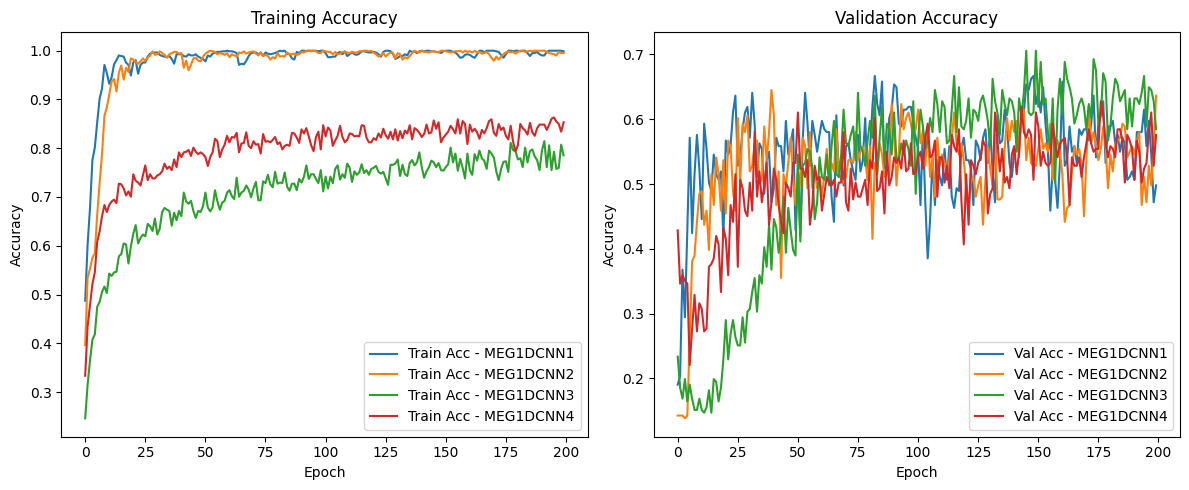

In [ ]:
import time

results_list = []; dropout_results_list = []
list_of_models = [MEG1DCNN1, MEG1DCNN2, MEG1DCNN3, MEG1DCNN4]

for i in range(len(list_of_models)):
    # select model per iteration    
    model = list_of_models[i](dropout=0.5).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    print(f"\nTraining model: {list_of_models[i].__name__}, \nNumber of parameters: {sum(p.numel() for p in model.parameters())}")

    start_time = time.time()
    history, best_model, test_acc, best_val_acc = train(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        device,
        epochs=100
    )
    end_time = time.time() - start_time
    print(f"Training time: {end_time:.2f} seconds")

    results = {
        "model": list_of_models[i].__name__,
        "history": history,
        "test_acc": test_acc,
        "time": end_time,
        "best_val_acc": best_val_acc
    }
    results_list.append(results)


# print the results in a table
print("\n\n ============== Final Results: ==============")
print(f"{'Model':<15} {'Test Acc':<10} {'Best Val Acc':<12} {'Time (s)':<10}")
for res in results_list:
    print(f"{res['model']:<15} {res['test_acc']:<10.4f} {res['best_val_acc']:<12.4f} {res['time']:<10.2f}")

    
# plot the train and validation accuracies in seperate plots. Plot train in one subplot and validation in another
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for i in range(len(list_of_models)):
    plt.plot(results_list[i]["history"]["train_acc"], label=f"Train Acc - {results_list[i]['model']}")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


plt.subplot(1, 2, 2)
for i in range(len(list_of_models)):
    plt.plot(results_list[i]["history"]["val_acc"], label=f"Val Acc - {results_list[i]['model']}")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()



#### Add smaller model, likely overfitting

In [ ]:
model = MEG1DCNN3(dropout=0.5).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-3)

num_epochs = 40
best_val_acc = 0
best_state = None

history_small = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history_small["train_loss"].append(train_loss)
    history_small["train_acc"].append(train_acc)
    history_small["val_loss"].append(val_loss)
    history_small["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model.state_dict()

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.3f}"
    )

model.load_state_dict(best_state)

test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print("Best validation accuracy:", best_val_acc)
print("Intra-subject test accuracy:", test_acc)

Epoch 01/40 | train loss 1.2183 acc 0.434 | val loss 1.3784 acc 0.212
Epoch 02/40 | train loss 0.8977 acc 0.656 | val loss 1.3361 acc 0.286
Epoch 03/40 | train loss 0.7417 acc 0.755 | val loss 1.2356 acc 0.364
Epoch 04/40 | train loss 0.5760 acc 0.835 | val loss 1.4580 acc 0.290
Epoch 05/40 | train loss 0.4233 acc 0.915 | val loss 1.2541 acc 0.394
Epoch 06/40 | train loss 0.3401 acc 0.933 | val loss 1.2882 acc 0.381
Epoch 07/40 | train loss 0.2576 acc 0.960 | val loss 1.1405 acc 0.519
Epoch 08/40 | train loss 0.2105 acc 0.959 | val loss 1.1205 acc 0.515
Epoch 09/40 | train loss 0.1380 acc 0.988 | val loss 1.1785 acc 0.494
Epoch 10/40 | train loss 0.1184 acc 0.989 | val loss 1.0700 acc 0.506
Epoch 11/40 | train loss 0.0840 acc 0.998 | val loss 1.1249 acc 0.485
Epoch 12/40 | train loss 0.0915 acc 0.992 | val loss 1.0875 acc 0.537
Epoch 13/40 | train loss 0.1086 acc 0.982 | val loss 1.2557 acc 0.537
Epoch 14/40 | train loss 0.0683 acc 0.998 | val loss 1.0489 acc 0.602
Epoch 15/40 | train 

#### Cross subject training

In [28]:
# Cross-subject grouped train/validation split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(
    gss.split(
        X_cross_train,
        y_cross_train,
        groups=files_cross_train
    )
)

X_train_cross = X_cross_train[train_idx]
y_train_cross = y_cross_train[train_idx]

X_val_cross = X_cross_train[val_idx]
y_val_cross = y_cross_train[val_idx]

print("Cross train:", X_train_cross.shape)
print("Cross val:", X_val_cross.shape)
print("Train files:", len(np.unique(files_cross_train[train_idx])))
print("Val files:", len(np.unique(files_cross_train[val_idx])))

print("Train class counts:", np.bincount(y_train_cross))
print("Val class counts:", np.bincount(y_val_cross))

Cross train: (1683, 248, 512)
Cross val: (429, 248, 512)
Train files: 51
Val files: 13
Train class counts: [396 429 396 462]
Val class counts: [132  99 132  66]


In [29]:
batch_size = 32

cross_train_loader = DataLoader(
    MEGWindowDataset(X_train_cross, y_train_cross),
    batch_size=batch_size,
    shuffle=True
)

cross_val_loader = DataLoader(
    MEGWindowDataset(X_val_cross, y_val_cross),
    batch_size=batch_size,
    shuffle=False
)

cross_test1_loader = DataLoader(
    MEGWindowDataset(X_cross_test1, y_cross_test1),
    batch_size=batch_size,
    shuffle=False
)

cross_test2_loader = DataLoader(
    MEGWindowDataset(X_cross_test2, y_cross_test2),
    batch_size=batch_size,
    shuffle=False
)

cross_test3_loader = DataLoader(
    MEGWindowDataset(X_cross_test3, y_cross_test3),
    batch_size=batch_size,
    shuffle=False
)

In [ ]:
# model_cross = MEG1DCNN(dropout=0.3).to(device)
model_cross = MEG1DCNN3(dropout=0.5).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model_cross.parameters(),
    lr=3e-4,
    weight_decay=1e-3
)

num_epochs = 40
best_val_acc = 0
best_state = None

history_cross = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model_cross,
        cross_train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, val_acc = evaluate(
        model_cross,
        cross_val_loader,
        criterion,
        device
    )

    history_cross["train_loss"].append(train_loss)
    history_cross["train_acc"].append(train_acc)
    history_cross["val_loss"].append(val_loss)
    history_cross["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model_cross.state_dict()

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.3f}"
    )

model_cross.load_state_dict(best_state)

Epoch 01/40 | train loss 1.1744 acc 0.462 | val loss 1.0425 acc 0.510
Epoch 02/40 | train loss 0.8731 acc 0.660 | val loss 0.9599 acc 0.587
Epoch 03/40 | train loss 0.6620 acc 0.765 | val loss 0.9387 acc 0.643
Epoch 04/40 | train loss 0.5103 acc 0.849 | val loss 0.8222 acc 0.648
Epoch 05/40 | train loss 0.3815 acc 0.900 | val loss 0.7501 acc 0.704
Epoch 06/40 | train loss 0.2986 acc 0.914 | val loss 0.8024 acc 0.692
Epoch 07/40 | train loss 0.1969 acc 0.966 | val loss 0.7917 acc 0.716
Epoch 08/40 | train loss 0.1897 acc 0.957 | val loss 0.7852 acc 0.718
Epoch 09/40 | train loss 0.1503 acc 0.967 | val loss 0.6198 acc 0.748
Epoch 10/40 | train loss 0.1094 acc 0.981 | val loss 0.7466 acc 0.716
Epoch 11/40 | train loss 0.1552 acc 0.958 | val loss 0.6364 acc 0.762
Epoch 12/40 | train loss 0.0895 acc 0.983 | val loss 0.6373 acc 0.772
Epoch 13/40 | train loss 0.0873 acc 0.983 | val loss 0.5630 acc 0.797
Epoch 14/40 | train loss 0.0928 acc 0.982 | val loss 0.7672 acc 0.748
Epoch 15/40 | train 

<All keys matched successfully>

In [31]:
cross_test1_loss, cross_test1_acc = evaluate(
    model_cross,
    cross_test1_loader,
    criterion,
    device
)

cross_test2_loss, cross_test2_acc = evaluate(
    model_cross,
    cross_test2_loader,
    criterion,
    device
)

cross_test3_loss, cross_test3_acc = evaluate(
    model_cross,
    cross_test3_loader,
    criterion,
    device
)

print("Best cross validation accuracy:", best_val_acc)
print("Cross test1 accuracy:", cross_test1_acc)
print("Cross test2 accuracy:", cross_test2_acc)
print("Cross test3 accuracy:", cross_test3_acc)

print("\nMean cross-subject test accuracy:")
print(np.mean([cross_test1_acc, cross_test2_acc, cross_test3_acc]))

Best cross validation accuracy: 0.8251748251748252
Cross test1 accuracy: 0.4602272727272727
Cross test2 accuracy: 0.4678030303030303
Cross test3 accuracy: 0.5587121212121212

Mean cross-subject test accuracy:
0.4955808080808081


## Confusion matrices

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

def get_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            logits = model(X_batch)
            preds = logits.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    return np.array(all_labels), np.array(all_preds)

class_names = [LABEL_TO_TASK[i] for i in range(4)]
class_names

['rest', 'task_story_math', 'task_working_memory', 'task_motor']

<Figure size 800x600 with 0 Axes>

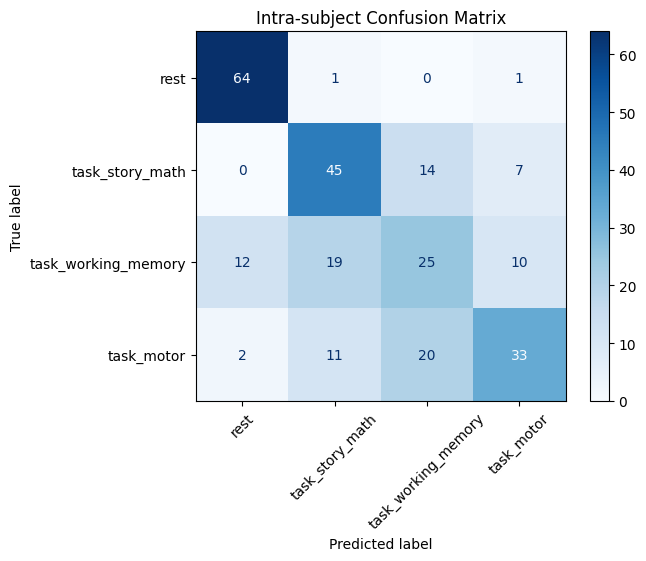

                     precision    recall  f1-score   support

               rest       0.82      0.97      0.89        66
    task_story_math       0.59      0.68      0.63        66
task_working_memory       0.42      0.38      0.40        66
         task_motor       0.65      0.50      0.56        66

           accuracy                           0.63       264
          macro avg       0.62      0.63      0.62       264
       weighted avg       0.62      0.63      0.62       264



In [33]:
y_true_intra, y_pred_intra = get_predictions(model, test_loader, device)

cm_intra = confusion_matrix(y_true_intra, y_pred_intra)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_intra,
    display_labels=class_names
)

plt.figure(figsize=(8, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Intra-subject Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

print(classification_report(
    y_true_intra,
    y_pred_intra,
    target_names=class_names
))

<Figure size 800x600 with 0 Axes>

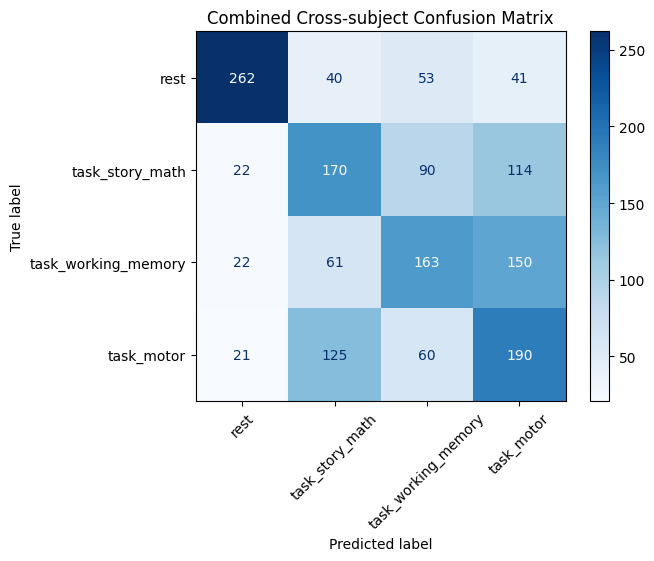

                     precision    recall  f1-score   support

               rest       0.80      0.66      0.72       396
    task_story_math       0.43      0.43      0.43       396
task_working_memory       0.45      0.41      0.43       396
         task_motor       0.38      0.48      0.43       396

           accuracy                           0.50      1584
          macro avg       0.51      0.50      0.50      1584
       weighted avg       0.51      0.50      0.50      1584



In [34]:
all_y_true_cross = []
all_y_pred_cross = []

for loader in [cross_test1_loader, cross_test2_loader, cross_test3_loader]:
    y_true_cross, y_pred_cross = get_predictions(model_cross, loader, device)
    all_y_true_cross.append(y_true_cross)
    all_y_pred_cross.append(y_pred_cross)

all_y_true_cross = np.concatenate(all_y_true_cross)
all_y_pred_cross = np.concatenate(all_y_pred_cross)

cm_cross_all = confusion_matrix(all_y_true_cross, all_y_pred_cross)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cross_all,
    display_labels=class_names
)

plt.figure(figsize=(8, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Combined Cross-subject Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

print(classification_report(
    all_y_true_cross,
    all_y_pred_cross,
    target_names=class_names
))